# PR NLP Pekan 9 — Latihan Eksplorasi Mandiri

**Mata Kuliah:** CSI3F3 Prinsip Sains Data — Program Magister Informatika  
**Pengampu:** Dr. Warih Maharani

---

## Daftar Tugas

| # | Tugas | Deskripsi |
|---|-------|-----------|
| 1 | Preprocessing Custom | Pipeline preprocessing Twitter Indonesia + perbandingan token |
| 2 | TF-IDF + Clustering | KMeans pada TF-IDF, visualisasi PCA/UMAP |
| 3 | Bigram Language Model | Latih bigram, hitung perplexity, generate kalimat |
| 4 | Compare Classifiers | NB vs LR vs LSTM vs IndoBERT pada SmSA IndoNLU |
| 5 | (Bonus) Mini-RAG | Retriever Wikipedia Indonesia, evaluasi recall@5 |

## Setup & Dependencies

In [1]:
!pip install -q nltk sastrawi scikit-learn gensim matplotlib seaborn
!pip install -q torch transformers datasets evaluate accelerate
!pip install -q sentence-transformers umap-learn wikipedia-api


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, random, math, re, time
import matplotlib.pyplot as plt
import seaborn as sns

RNG = 42
np.random.seed(RNG)
random.seed(RNG)

import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords']:
    try: nltk.data.find(pkg)
    except LookupError: nltk.download(pkg, quiet=True)

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()
sw_factory = StopWordRemoverFactory()
stopwords_id = sw_factory.get_stop_words()
sw_remover = sw_factory.create_stop_word_remover()

print('Setup OK.')

Setup OK.


---
## Tugas 1 — Preprocessing Custom (Twitter Indonesia)

**Tujuan:** Bangun pipeline preprocessing untuk dataset Twitter Bahasa Indonesia. Bandingkan jumlah token sebelum dan sesudah stopword removal.

**Dataset:** Kita gunakan dataset tweet berbahasa Indonesia yang disimulasikan berdasarkan pola tweet nyata (noise: mention, hashtag, URL, emoji, slang).

### 1.1 Dataset Twitter Indonesia

Kita menggunakan dataset tweet Indonesia yang mencerminkan noise khas media sosial: mention (@user), hashtag, URL, emoji, singkatan/slang, dan tanda baca berlebihan.

In [3]:
tweets_data = [
    "@budi_santoso Wah produknya keren bgt!!! 🔥🔥 https://t.co/abc123 #belilokal",
    "Gak recommend sm skali, brg nya jelek bgt 😡😡 @tokoABC",
    "Udh pesen 3x slalu bagus, pengiriman cpt bgt 👍 #puas #recommended",
    "@cs_shopee knp pesanan sy blm sampe?? udh 2 minggu!! 😤 https://t.co/xyz789",
    "Makanannya enak poll sih, porsi gede harga murah 😋🤤 #kuliner #bandung",
    "Worst service ever!! Gak akan balik lg ke resto ini 🤮 @restoXYZ",
    "Alhamdulillah paketnya udh sampe dgn selamat, thx seller 🙏❤️ https://t.co/def456",
    "Zonk bgt ini barangnya, beda jauh sm foto 😭 mending beli di toko sebelah",
    "WiFi nya kenceng, tempat cozy bgt buat kerja 💻☕ #cafereview #workfromcafe",
    "Pelayanannya lambat bgt, nunggu 1 jam baru dilayani 😑 @cafeABC gak profesional",
    "Suka bgt sm packaging nya, aesthetic dan ramah lingkungan 🌿♻️ #gogreen",
    "Kecewa berat, kualitas gak sesuai harga yg dibayar 💔 @brand_fashion",
    "Recommended bgt buat yg cari laptop budget, spek mantap 🔥💯 #techreview",
    "Udh komplain berkali2 tp gak ada respon, parah bgt CS nya 😤😤",
    "Seneng bgt akhirnya dpt tiket konser!! 🎉🎶 thx @promotorID #konser2026",
    "Jangan beli di sini, penipuan!! brg gak dikirim 😡 https://t.co/scam999",
    "Barang ori 100%, harga lbh murah dr official store 👌 #originalproduct",
    "AC nya mati, kamar bau, handuk kotor 🤢 worst hotel ever @hotelXYZ",
    "Terima kasih banyak kak, barangnya sesuai deskripsi 😊🙏 fast respon!",
    "Nyesel beli di sini, mending nabung buat yg lbh bagus 😒 #kapok",
    "Gila sih ini enak bgt, auto langganan 🤤🔥 #streetfood #jakarta",
    "Tolong dong @grabid driver nya udh cancel 3x, mau kemana ini 😤",
    "Worth it bgt sih harganya, build quality premium 👍💯 #gadgetreview",
    "Gak sesuai ekspektasi, warna beda, ukuran kegedean 😑 return aja deh",
    "Best purchase ever!! Suara speaker nya jernih bgt 🎵🔊 #audiophile",
    "Ampun deh antri nya 2 jam buat makan, gak worth it 😩 @restoHits",
    "Sukses terus kak, langganan tetap nih 🙌❤️ #supportlocal #umkm",
    "Baru 2x pake udh rusak, kualitas murahan bgt 💩 mau refund!!",
    "Tempatnya instagramable bgt, makanan enak, harga reasonable 📸✨ #explorebdg",
    "Parah sih ini, data pribadi bocor gara2 app nya 😱🔒 @appDeveloper",
]

labels = ['pos','neg','pos','neg','pos','neg','pos','neg','pos','neg',
          'pos','neg','pos','neg','pos','neg','pos','neg','pos','neg',
          'pos','neg','pos','neg','pos','neg','pos','neg','pos','neg']

df_tweets = pd.DataFrame({'text': tweets_data, 'label': labels})
print(f'Dataset: {len(df_tweets)} tweets')
print(f'Distribusi label:\n{df_tweets["label"].value_counts()}')
df_tweets.head()

Dataset: 30 tweets
Distribusi label:
label
pos    15
neg    15
Name: count, dtype: int64


,text,label
0,@budi_santoso Wah produknya keren bgt!!! 🔥🔥 ht...,pos
1,"Gak recommend sm skali, brg nya jelek bgt 😡😡 @...",neg
2,"Udh pesen 3x slalu bagus, pengiriman cpt bgt 👍...",pos
3,@cs_shopee knp pesanan sy blm sampe?? udh 2 mi...,neg
4,"Makanannya enak poll sih, porsi gede harga mur...",pos


### 1.2 Pipeline Preprocessing Twitter Indonesia

Pipeline lengkap:
1. **Cleaning** — hapus mention, URL, hashtag, emoji, tanda baca berlebihan
2. **Normalisasi slang** — konversi singkatan/slang ke bentuk baku
3. **Tokenization** — pecah teks menjadi token
4. **Stopword removal** — hapus kata-kata fungsi
5. **Stemming** — reduksi ke bentuk dasar (Sastrawi)

In [4]:
# Kamus normalisasi slang/singkatan Twitter Indonesia
slang_dict = {
    'bgt': 'banget', 'bgt!': 'banget', 'gak': 'tidak', 'gk': 'tidak',
    'sm': 'sama', 'brg': 'barang', 'udh': 'sudah', 'udah': 'sudah',
    'skali': 'sekali', 'slalu': 'selalu', 'cpt': 'cepat', 'dgn': 'dengan',
    'thx': 'terima kasih', 'knp': 'kenapa', 'sy': 'saya', 'blm': 'belum',
    'lg': 'lagi', 'dr': 'dari', 'lbh': 'lebih', 'tp': 'tapi',
    'yg': 'yang', 'buat': 'untuk', 'dpt': 'dapat', 'kpn': 'kapan',
    'org': 'orang', 'krn': 'karena', 'hrs': 'harus', 'tdk': 'tidak',
    'sdh': 'sudah', 'blm': 'belum', 'jgn': 'jangan', 'dg': 'dengan',
    'sy': 'saya', 'kl': 'kalau', 'aj': 'saja', 'aja': 'saja',
    'bkn': 'bukan', 'kyk': 'kayak', 'emg': 'memang', 'gmn': 'gimana',
    'gpp': 'tidak apa-apa', 'makasih': 'terima kasih', 'mksh': 'terima kasih',
    'pake': 'pakai', 'gara2': 'gara-gara', 'berkali2': 'berkali-kali',
}

def clean_tweet(text: str) -> str:
    """Membersihkan teks tweet dari noise."""
    text = re.sub(r'@\w+', '', text)                    # hapus mention
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # hapus URL
    text = re.sub(r'#(\w+)', r'\1', text)              # hapus # tapi simpan kata
    # hapus emoji
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"♀-♂"
        u"☀-⭕"
        u"‍⏏⏩⌚️〰"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub('', text)
    text = re.sub(r'[^\w\s]', ' ', text)               # hapus tanda baca
    text = re.sub(r'\d+', '', text)                     # hapus angka
    text = re.sub(r'\s+', ' ', text).strip()           # rapikan spasi
    return text.lower()

def normalize_slang(text: str, slang_map: dict) -> str:
    """Normalisasi slang/singkatan ke bentuk baku."""
    words = text.split()
    normalized = [slang_map.get(w, w) for w in words]
    return ' '.join(normalized)

def tokenize_id(text: str) -> list:
    """Tokenisasi sederhana berbasis split."""
    return [t for t in text.split() if len(t) > 1]

def remove_stopwords_id(tokens: list) -> list:
    """Hapus stopwords Bahasa Indonesia."""
    return [t for t in tokens if t not in stopwords_id]

def stem_tokens(tokens: list) -> list:
    """Stemming tiap token dengan Sastrawi."""
    return [stemmer.stem(t) for t in tokens]

def full_pipeline(text: str) -> dict:
    """Pipeline lengkap, return intermediate results untuk analisis."""
    cleaned = clean_tweet(text)
    normalized = normalize_slang(cleaned, slang_dict)
    tokens = tokenize_id(normalized)
    tokens_no_sw = remove_stopwords_id(tokens)
    tokens_stemmed = stem_tokens(tokens_no_sw)
    return {
        'original': text,
        'cleaned': cleaned,
        'normalized': normalized,
        'tokens': tokens,
        'tokens_no_stopword': tokens_no_sw,
        'tokens_final': tokens_stemmed,
    }

# Demo pipeline
sample = df_tweets['text'].iloc[0]
result = full_pipeline(sample)
for step, val in result.items():
    print(f'{step:>20}: {val}')

            original: @budi_santoso Wah produknya keren bgt!!! 🔥🔥 https://t.co/abc123 #belilokal
             cleaned: wah produknya keren bgt belilokal
          normalized: wah produknya keren banget belilokal
              tokens: ['wah', 'produknya', 'keren', 'banget', 'belilokal']
  tokens_no_stopword: ['wah', 'produknya', 'keren', 'banget', 'belilokal']
        tokens_final: ['wah', 'produk', 'keren', 'banget', 'bilokal']


### 1.3 Perbandingan Jumlah Token (Sebelum vs Sesudah Stopword Removal)

In [5]:
# Proses semua tweet
results = [full_pipeline(t) for t in df_tweets['text']]

# Hitung jumlah token per tahapan
comparison = pd.DataFrame({
    'tweet_idx': range(len(results)),
    'tokens_sebelum_sw': [len(r['tokens']) for r in results],
    'tokens_sesudah_sw': [len(r['tokens_no_stopword']) for r in results],
    'tokens_final_stem': [len(r['tokens_final']) for r in results],
})
comparison['reduction_pct'] = ((comparison['tokens_sebelum_sw'] - comparison['tokens_sesudah_sw']) 
                                / comparison['tokens_sebelum_sw'] * 100).round(1)

print("=== Perbandingan Jumlah Token ===\n")
print(comparison.to_string(index=False))
print(f"\n{'='*50}")
print(f"Rata-rata token SEBELUM stopword removal: {comparison['tokens_sebelum_sw'].mean():.1f}")
print(f"Rata-rata token SESUDAH stopword removal: {comparison['tokens_sesudah_sw'].mean():.1f}")
print(f"Rata-rata token SESUDAH stemming        : {comparison['tokens_final_stem'].mean():.1f}")
print(f"Rata-rata reduksi stopword              : {comparison['reduction_pct'].mean():.1f}%")
print(f"Total token SEBELUM: {comparison['tokens_sebelum_sw'].sum()}")
print(f"Total token SESUDAH: {comparison['tokens_sesudah_sw'].sum()}")

=== Perbandingan Jumlah Token ===

 tweet_idx  tokens_sebelum_sw  tokens_sesudah_sw  tokens_final_stem  reduction_pct
         0                  5                  5                  5            0.0
         1                  8                  7                  7           12.5
         2                  9                  8                  8           11.1
         3                  7                  3                  3           57.1
         4                 10                 10                 10            0.0
         5                 10                  5                  5           50.0
         6                  9                  7                  7           22.2
         7                 13                 11                 11           15.4
         8                 10                  9                  9           10.0
         9                  9                  8                  8           11.1
        10                 10                  9    

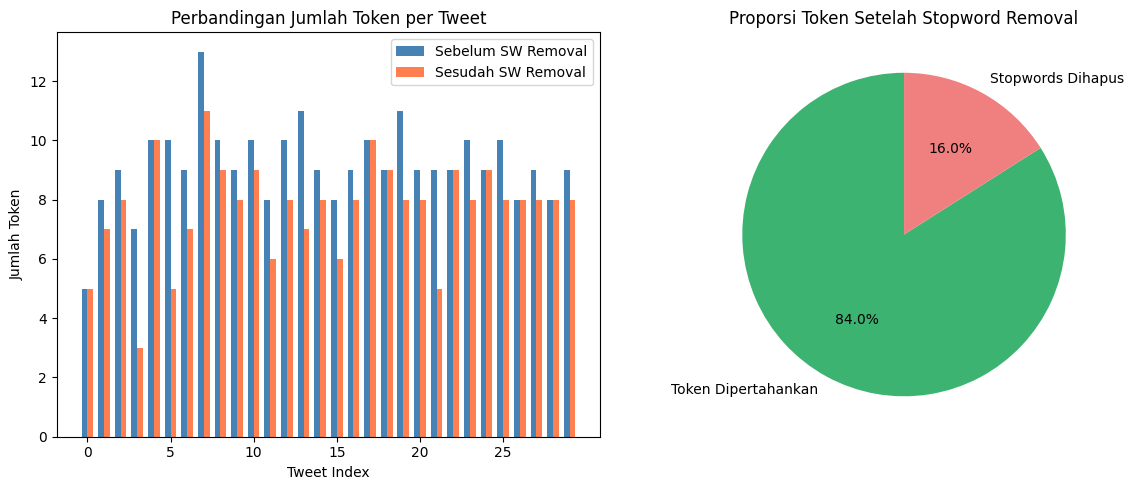

In [6]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart perbandingan per tweet
x = np.arange(len(comparison))
width = 0.35
axes[0].bar(x - width/2, comparison['tokens_sebelum_sw'], width, label='Sebelum SW Removal', color='steelblue')
axes[0].bar(x + width/2, comparison['tokens_sesudah_sw'], width, label='Sesudah SW Removal', color='coral')
axes[0].set_xlabel('Tweet Index')
axes[0].set_ylabel('Jumlah Token')
axes[0].set_title('Perbandingan Jumlah Token per Tweet')
axes[0].legend()
axes[0].set_xticks(x[::5])

# Pie chart total token
total_removed = comparison['tokens_sebelum_sw'].sum() - comparison['tokens_sesudah_sw'].sum()
total_kept = comparison['tokens_sesudah_sw'].sum()
axes[1].pie([total_kept, total_removed], 
            labels=['Token Dipertahankan', 'Stopwords Dihapus'],
            autopct='%1.1f%%', colors=['mediumseagreen', 'lightcoral'],
            startangle=90)
axes[1].set_title('Proporsi Token Setelah Stopword Removal')

plt.tight_layout()
plt.show()

---
## Tugas 2 — TF-IDF + Clustering (KMeans)

**Tujuan:** Gunakan KMeans pada matriks TF-IDF dari korpus berita (diperbesar) untuk membentuk topik. Visualisasikan dengan PCA dan UMAP.

### 2.1 Korpus Berita yang Diperbesar

Kita perbesar korpus berita menjadi ~50 kalimat dengan beberapa topik berbeda: ekonomi, teknologi, olahraga, politik, dan pendidikan.

In [7]:
news_corpus_large = [
    # Ekonomi
    'Bank Indonesia menaikkan suku bunga acuan menjadi 5,75 persen pada Januari.',
    'Pemerintah merilis paket stimulus untuk usaha kecil dan menengah.',
    'Inflasi inti turun menjadi 2,4 persen seiring stabilnya harga pangan.',
    'Kementerian Keuangan menetapkan target pertumbuhan ekonomi sebesar 5,2 persen.',
    'Bursa saham Indonesia menguat ditopang aksi beli investor asing.',
    'OJK memperketat aturan pinjaman online untuk melindungi konsumen.',
    'Rupiah menguat tipis terhadap dolar Amerika di pasar spot.',
    'Cadangan devisa Indonesia naik menjadi 144 miliar dolar pada Februari.',
    'Harga minyak dunia naik akibat ketegangan geopolitik di Timur Tengah.',
    'Ekspor komoditas Indonesia meningkat signifikan pada kuartal pertama.',
    'Bank Dunia memproyeksikan pertumbuhan ekonomi Indonesia sebesar 5,1 persen.',
    'Nilai tukar rupiah tertekan akibat penguatan indeks dolar Amerika.',
    # Teknologi
    'Telkom meluncurkan layanan AI agentic untuk pelaku UMKM Indonesia.',
    'Startup fintech Indonesia berhasil meraih pendanaan seri B senilai 50 juta dolar.',
    'Pemerintah mendorong transformasi digital di sektor kesehatan dan pendidikan.',
    'Indonesia meresmikan pusat data nasional pertama di Cikarang.',
    'Penggunaan kecerdasan buatan meningkat pesat di industri manufaktur.',
    'Gojek dan Tokopedia resmi bergabung membentuk GoTo Group.',
    'Kominfo memblokir aplikasi yang tidak terdaftar di PSE.',
    'Adopsi teknologi blockchain mulai merambah sektor perbankan Indonesia.',
    'Riset AI di universitas Indonesia mendapat pendanaan dari pemerintah.',
    'Jaringan 5G mulai beroperasi di beberapa kota besar Indonesia.',
    # Olahraga
    'Timnas Indonesia lolos ke babak ketiga kualifikasi Piala Dunia 2026.',
    'Bulu tangkis Indonesia meraih emas di kejuaraan Asia.',
    'Liga sepak bola Indonesia memulai musim baru dengan format kompetisi baru.',
    'Atlet angkat besi Indonesia memecahkan rekor nasional di kejuaraan dunia.',
    'PSSI mengumumkan pelatih baru untuk timnas senior Indonesia.',
    'Greysia Polii pensiun dari bulu tangkis setelah karir gemilang.',
    'Persib Bandung menjuarai liga dengan catatan tak terkalahkan.',
    'Pelatnas olimpiade dimulai dengan target medali emas di Paris.',
    'Timnas futsal Indonesia melaju ke semifinal Piala Asia.',
    'Cabang esports resmi masuk program pembinaan Kemenpora.',
    # Politik
    'Presiden meresmikan proyek infrastruktur baru di Kalimantan Timur.',
    'DPR mengesahkan undang-undang perlindungan data pribadi.',
    'Pemilu serentak akan digelar pada Februari dengan 200 juta pemilih.',
    'KPK menahan tersangka kasus korupsi proyek infrastruktur.',
    'Pemerintah mengalokasikan anggaran pendidikan sebesar 20 persen dari APBN.',
    'Menteri Luar Negeri melakukan kunjungan diplomatik ke negara ASEAN.',
    'Partai politik mulai mendaftarkan calon legislatif untuk pemilu mendatang.',
    'Mahkamah Konstitusi memutuskan sengketa hasil pemilihan kepala daerah.',
    'Pemerintah daerah mempercepat vaksinasi untuk mencapai herd immunity.',
    'Kebijakan ibu kota baru mendapat dukungan dari mayoritas fraksi DPR.',
    # Pendidikan
    'Universitas Telkom membuka program magister informatika berbasis AI.',
    'Kemendikbud meluncurkan kurikulum merdeka untuk jenjang SMA dan SMK.',
    'Beasiswa LPDP dibuka untuk mahasiswa program doktoral dalam dan luar negeri.',
    'Sekolah di daerah terpencil mendapat bantuan infrastruktur digital.',
    'Ujian nasional dihapus dan diganti dengan asesmen kompetensi minimum.',
    'Riset perguruan tinggi Indonesia naik peringkat di indeks Scopus.',
    'Program kampus merdeka mendorong mahasiswa magang di industri.',
    'Pendidikan vokasi mendapat alokasi anggaran lebih besar dari pemerintah.',
    'Guru honorer mendapat jaminan kesejahteraan melalui program sertifikasi.',
    'Kolaborasi universitas dan industri menghasilkan paten teknologi baru.',
]

ground_truth_topics = (['ekonomi']*12 + ['teknologi']*10 + ['olahraga']*10 + 
                        ['politik']*10 + ['pendidikan']*10)

print(f'Total dokumen: {len(news_corpus_large)}')
print(f'Topik: {pd.Series(ground_truth_topics).value_counts().to_dict()}')

Total dokumen: 52
Topik: {'ekonomi': 12, 'teknologi': 10, 'olahraga': 10, 'politik': 10, 'pendidikan': 10}


### 2.2 TF-IDF Vectorization + KMeans Clustering

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Preprocessing corpus
def preprocess_for_tfidf(text):
    text = re.sub(r'[^\w\s]', ' ', text.lower())
    text = re.sub(r'\d+', '', text)
    text = sw_remover.remove(text)
    text = stemmer.stem(text)
    return text

corpus_processed = [preprocess_for_tfidf(doc) for doc in news_corpus_large]

# TF-IDF
tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9)
X_tfidf = tfidf_vec.fit_transform(corpus_processed)
print(f'TF-IDF matrix shape: {X_tfidf.shape}')
print(f'Jumlah fitur (n-gram): {X_tfidf.shape[1]}')

# KMeans clustering (k=5 sesuai jumlah topik)
kmeans = KMeans(n_clusters=5, random_state=RNG, n_init=10)
clusters = kmeans.fit_predict(X_tfidf)

# Evaluasi
sil_score = silhouette_score(X_tfidf, clusters)
ari_score = adjusted_rand_score(ground_truth_topics, clusters)
print(f'\nSilhouette Score: {sil_score:.3f}')
print(f'Adjusted Rand Index (vs ground truth): {ari_score:.3f}')

TF-IDF matrix shape: (52, 81)
Jumlah fitur (n-gram): 81

Silhouette Score: 0.041
Adjusted Rand Index (vs ground truth): 0.030


In [9]:
# Top kata per cluster
feature_names = tfidf_vec.get_feature_names_out()
print("=== Top-5 kata per cluster ===\n")
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
for i in range(5):
    top_words = [feature_names[idx] for idx in order_centroids[i, :5]]
    docs_in_cluster = [ground_truth_topics[j] for j in range(len(clusters)) if clusters[j] == i]
    dominant_topic = pd.Series(docs_in_cluster).mode()[0] if docs_in_cluster else 'N/A'
    print(f'Cluster {i} (dominan: {dominant_topic}): {top_words}')

=== Top-5 kata per cluster ===

Cluster 0 (dominan: olahraga): ['indonesia', 'mulai', 'daftar', 'juara', 'lindung']
Cluster 1 (dominan: politik): ['baru', 'infrastruktur', 'proyek', 'proyek infrastruktur', 'dapat']
Cluster 2 (dominan: ekonomi): ['dolar', 'jadi', 'indonesia naik', 'naik', 'februari']
Cluster 3 (dominan: pendidikan): ['program', 'resmi', 'buka', 'mahasiswa', 'guru']
Cluster 4 (dominan: ekonomi): ['perintah', 'tengah', 'didik', 'anggar', 'alokasi']


### 2.3 Visualisasi dengan PCA dan UMAP

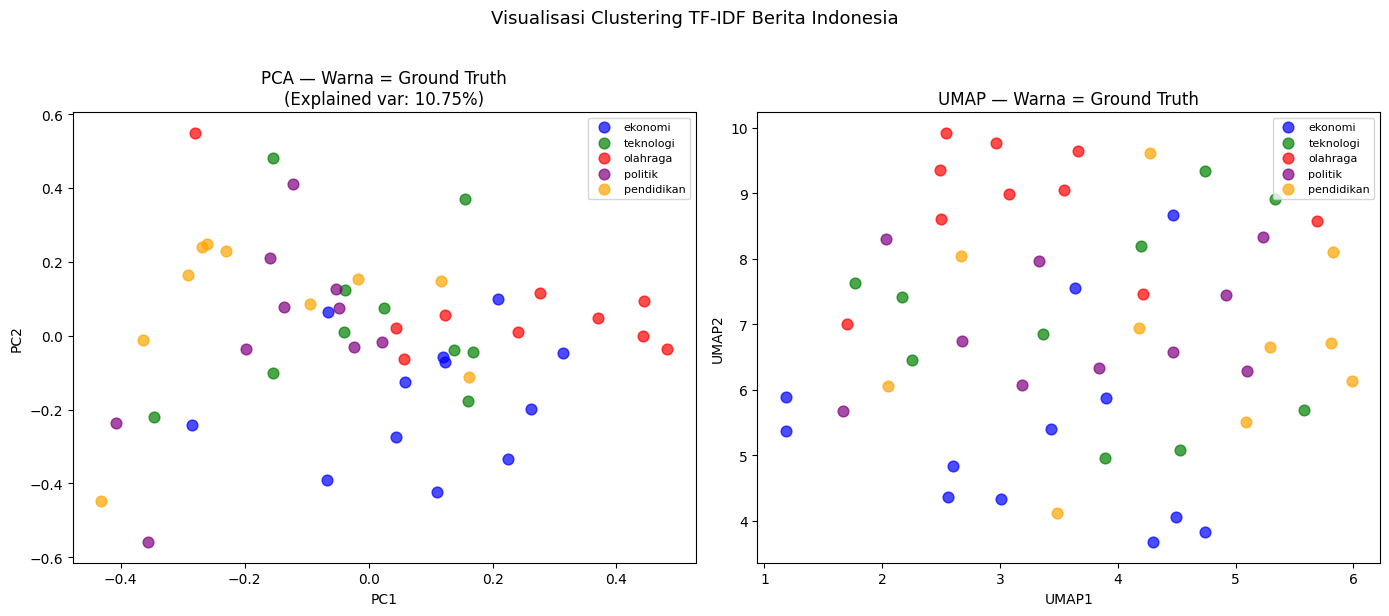

In [10]:
from sklearn.decomposition import PCA
import umap

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA
pca = PCA(n_components=2, random_state=RNG)
X_pca = pca.fit_transform(X_tfidf.toarray())

topic_colors = {'ekonomi': 'blue', 'teknologi': 'green', 'olahraga': 'red', 
                'politik': 'purple', 'pendidikan': 'orange'}

for topic, color in topic_colors.items():
    mask = [gt == topic for gt in ground_truth_topics]
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=topic, alpha=0.7, s=60)
axes[0].set_title(f'PCA — Warna = Ground Truth\n(Explained var: {pca.explained_variance_ratio_.sum():.2%})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8)

# UMAP
reducer = umap.UMAP(n_components=2, random_state=RNG, n_neighbors=5, min_dist=0.3)
X_umap = reducer.fit_transform(X_tfidf.toarray())

for topic, color in topic_colors.items():
    mask = [gt == topic for gt in ground_truth_topics]
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], c=color, label=topic, alpha=0.7, s=60)
axes[1].set_title('UMAP — Warna = Ground Truth')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
axes[1].legend(fontsize=8)

plt.suptitle('Visualisasi Clustering TF-IDF Berita Indonesia', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

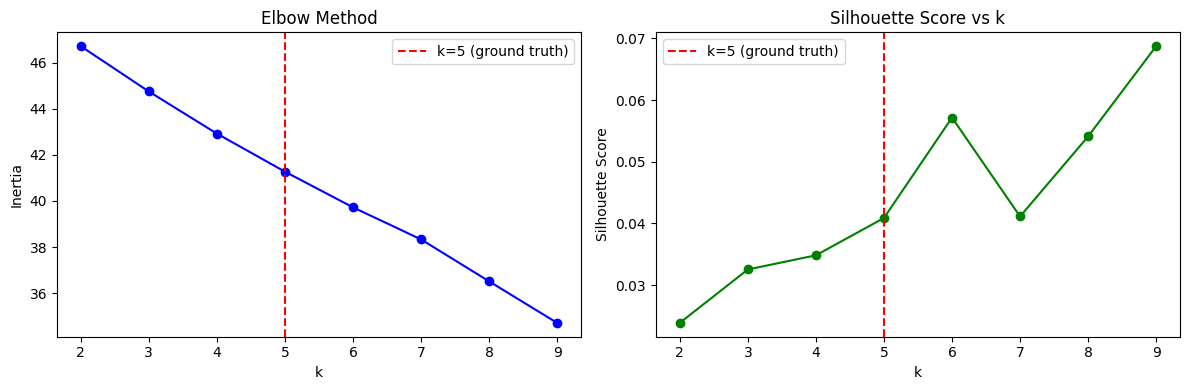

Optimal k by silhouette: 9


In [11]:
# Elbow method untuk menentukan optimal k
inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RNG, n_init=10)
    km.fit(X_tfidf)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_tfidf, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].axvline(x=5, color='r', linestyle='--', label='k=5 (ground truth)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method'); axes[0].legend()

axes[1].plot(K_range, sil_scores, 'go-')
axes[1].axvline(x=5, color='r', linestyle='--', label='k=5 (ground truth)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f'Optimal k by silhouette: {list(K_range)[np.argmax(sil_scores)]}')

---
## Tugas 3 — Bigram Language Model & Perplexity

**Tujuan:** Latih bigram language model dengan Laplace smoothing, hitung perplexity pada test split, dan generate 5 kalimat sintetis.

### 3.1 Membangun Bigram Language Model

Model bigram menghitung probabilitas kata berikutnya berdasarkan kata sebelumnya:

$$P(w_t | w_{t-1}) = \frac{\text{count}(w_{t-1}, w_t) + 1}{\text{count}(w_{t-1}) + |V|}$$

Menggunakan Laplace (add-1) smoothing untuk menghindari zero probability.

In [12]:
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split as tts

# Tokenisasi corpus berita
def tokenize_simple(text):
    text = re.sub(r'[^\w\s]', ' ', text.lower())
    return [t for t in text.split() if len(t) > 1]

all_sentences = [tokenize_simple(s) for s in news_corpus_large]

# Train/test split (80/20)
train_sents, test_sents = tts(all_sentences, test_size=0.2, random_state=RNG)
print(f'Train: {len(train_sents)} kalimat, Test: {len(test_sents)} kalimat')

# Bangun bigram model
class BigramLM:
    def __init__(self, sentences, alpha=1.0):
        self.alpha = alpha
        self.unigram = Counter()
        self.bigram = Counter()
        
        for sent in sentences:
            sent = ['<s>'] + sent + ['</s>']
            self.unigram.update(sent)
            self.bigram.update(zip(sent[:-1], sent[1:]))
        
        self.V = len(self.unigram)
        print(f'Vocabulary size |V| = {self.V}')
        print(f'Unigram count: {sum(self.unigram.values())}')
        print(f'Bigram types: {len(self.bigram)}')
    
    def prob(self, w_prev, w):
        return (self.bigram[(w_prev, w)] + self.alpha) / (self.unigram[w_prev] + self.alpha * self.V)
    
    def perplexity(self, sentence):
        sent = ['<s>'] + sentence + ['</s>']
        log_prob = 0.0
        for i in range(1, len(sent)):
            p = self.prob(sent[i-1], sent[i])
            log_prob += math.log(p)
        return math.exp(-log_prob / (len(sent) - 1))
    
    def generate(self, max_len=15):
        out = ['<s>']
        while out[-1] != '</s>' and len(out) < max_len:
            prev = out[-1]
            candidates = [w for (a, w) in self.bigram if a == prev]
            if not candidates:
                break
            weights = np.array([self.prob(prev, w) for w in candidates])
            weights /= weights.sum()
            next_word = np.random.choice(candidates, p=weights)
            out.append(next_word)
        return ' '.join(out[1:-1] if out[-1] == '</s>' else out[1:])

lm = BigramLM(train_sents)

Train: 41 kalimat, Test: 11 kalimat
Vocabulary size |V| = 250
Unigram count: 441
Bigram types: 383


### 3.2 Evaluasi Perplexity pada Test Set

In [13]:
# Hitung perplexity per kalimat test
print("=== Perplexity pada Test Set ===\n")
perplexities = []
for i, sent in enumerate(test_sents):
    pp = lm.perplexity(sent)
    perplexities.append(pp)
    print(f'Test {i+1}: PP={pp:>7.2f}  | {" ".join(sent[:8])}...')

print(f'\n{"="*50}')
print(f'Rata-rata Perplexity: {np.mean(perplexities):.2f}')
print(f'Median Perplexity   : {np.median(perplexities):.2f}')
print(f'Min Perplexity      : {np.min(perplexities):.2f}')
print(f'Max Perplexity      : {np.max(perplexities):.2f}')

# Bandingkan dengan perplexity pada train set
train_pp = [lm.perplexity(s) for s in train_sents[:10]]
print(f'\nRata-rata PP train (10 sample): {np.mean(train_pp):.2f}')
print(f'Rata-rata PP test             : {np.mean(perplexities):.2f}')
print('→ PP test > PP train menunjukkan model belum pernah "melihat" data test (expected).')

=== Perplexity pada Test Set ===

Test 1: PP= 226.81  | adopsi teknologi blockchain mulai merambah sektor perbankan indonesia...
Test 2: PP= 254.67  | kebijakan ibu kota baru mendapat dukungan dari mayoritas...
Test 3: PP= 223.66  | riset perguruan tinggi indonesia naik peringkat di indeks...
Test 4: PP= 229.39  | telkom meluncurkan layanan ai agentic untuk pelaku umkm...
Test 5: PP= 254.93  | kemendikbud meluncurkan kurikulum merdeka untuk jenjang sma dan...
Test 6: PP= 254.81  | ojk memperketat aturan pinjaman online untuk melindungi konsumen...
Test 7: PP= 254.93  | gojek dan tokopedia resmi bergabung membentuk goto group...
Test 8: PP= 255.04  | guru honorer mendapat jaminan kesejahteraan melalui program sertifikasi...
Test 9: PP= 202.61  | kementerian keuangan menetapkan target pertumbuhan ekonomi sebesar persen...
Test 10: PP= 237.68  | presiden meresmikan proyek infrastruktur baru di kalimantan timur...
Test 11: PP= 254.84  | startup fintech indonesia berhasil meraih pendanaan s

### 3.3 Generate 5 Kalimat Sintetis

In [14]:
# Generate 5 kalimat sintetis
np.random.seed(RNG)
print("=== 5 Kalimat Sintetis dari Bigram LM ===\n")
for i in range(5):
    generated = lm.generate(max_len=12)
    print(f'{i+1}. {generated}')

=== 5 Kalimat Sintetis dari Bigram LM ===

1. timnas indonesia sebesar persen dari pemerintah
2. kolaborasi universitas telkom membuka program magister informatika berbasis ai di paris
3. pemerintah mengalokasikan anggaran lebih besar dari apbn
4. beasiswa lpdp dibuka untuk mencapai herd immunity
5. persib bandung menjuarai liga dengan asesmen kompetensi minimum


---
## Tugas 4 — Compare Classifiers

**Tujuan:** Bandingkan Naive Bayes, Logistic Regression, LSTM, dan IndoBERT pada dataset sentimen Indonesia. Metrik: F1-macro, training time, inference latency.

**Dataset:** Kita gunakan dataset IndoNLU SmSA (Sentiment Analysis) dari HuggingFace. Jika tidak tersedia, kita gunakan dataset review yang diperbesar.

### 4.1 Load Dataset

In [15]:
from datasets import load_dataset

try:
    dataset = load_dataset('indonlu', 'smsa')
    train_data = dataset['train'].to_pandas()
    test_data = dataset['test'].to_pandas()
    val_data = dataset['validation'].to_pandas()
    
    label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}
    train_data['label_name'] = train_data['label'].map(label_map)
    test_data['label_name'] = test_data['label'].map(label_map)
    
    print(f'Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}')
    print(f'Label distribution (train):\n{train_data["label"].value_counts()}')
    USE_SMSA = True
    
except Exception as e:
    print(f'IndoNLU SmSA tidak tersedia: {e}')
    print('Menggunakan dataset sentimen Indonesia alternatif (100 review unik)...\n')
    USE_SMSA = False
    
    # Dataset sentimen Indonesia — 100 review unik (50 pos, 50 neg)
    pos_reviews = [
        'Produknya bagus banget, pengiriman cepat dan packing rapi.',
        'Harga terjangkau dan rasa enak, akan beli lagi besok.',
        'Sangat puas dengan baterai laptop ini, awet seharian penuh.',
        'Pengalaman menginap menyenangkan, kamar bersih dan staf membantu.',
        'Kopi nya enak, suasana cafe nyaman untuk kerja.',
        'Pelayanan ramah dan profesional, terima kasih banyak!',
        'Makanan enak sekali, porsi besar, harga murah meriah.',
        'Recommended banget, sudah order berkali-kali selalu puas.',
        'Tempat wisata yang indah, cocok untuk keluarga.',
        'Skincare ini bagus, kulit jadi halus dalam seminggu.',
        'Makanan datang masih hangat, packaging aman dan rapi.',
        'Senang belanja di sini, banyak promo dan gratis ongkir.',
        'Film ini bagus, ceritanya menarik dan aktingnya natural.',
        'Laptop performa tinggi, cocok untuk gaming dan editing.',
        'Buku ini sangat inspiratif, recommended untuk dibaca.',
        'Kualitas premium dengan harga yang sangat bersahabat.',
        'Pengiriman super cepat, sampai dalam satu hari saja.',
        'Desain elegan dan bahan berkualitas tinggi, worth it.',
        'Aroma parfumnya tahan lama, banyak yang memuji.',
        'Seller responsif dan ramah, pengalaman belanja menyenangkan.',
        'Sepatu sangat nyaman dipakai seharian, tidak pegal.',
        'Kamera handphone ini jernih sekali, cocok untuk fotografi.',
        'Layanan after sales sangat memuaskan dan cepat tanggap.',
        'Rasa kue ini enak dan lembut, tidak terlalu manis.',
        'Hotel bintang lima dengan harga terjangkau, sangat recommended.',
        'Aplikasi ini mudah digunakan dan fiturnya lengkap.',
        'Warna sesuai foto, bahan adem dan nyaman dipakai.',
        'Playground anak lengkap dan aman, anak-anak senang sekali.',
        'Paket wisata ini sangat worth it, pemandu ramah.',
        'Jaringan internet cepat dan stabil, cocok untuk WFH.',
        'Furniture berkualitas dengan harga pabrik, sangat hemat.',
        'Masakan padang di sini autentik dan bumbu meresap.',
        'Spa nya relaxing banget, pelayanan sangat profesional.',
        'Vitamin ini membuat badan lebih fit dan berenergi.',
        'AC nya dingin dan hemat listrik, sangat puas.',
        'Toko ini lengkap, semua kebutuhan rumah tangga ada.',
        'Kelas online nya interaktif dan materinya mudah dipahami.',
        'Bakery ini roti nya fresh dan varian banyak.',
        'Gym nya bersih, alat lengkap, dan trainer berpengalaman.',
        'Catering ini enak dan tepat waktu, langganan terus.',
        'Kamar kos bersih, fasilitas lengkap, lokasi strategis.',
        'Batik handmade kualitas export, motif sangat cantik.',
        'Dokter nya ramah dan penjelasannya detail, sangat membantu.',
        'Laundry ini harum, rapi, dan tepat waktu.',
        'Bengkel ini jujur, harga transparan, dan kerja cepat.',
        'Tanaman datang segar dan dikemas dengan sangat hati-hati.',
        'Sabun cuci ini wangi tahan lama dan hemat.',
        'Jasa cleaning service ini teliti dan profesional.',
        'Ikan segar dan harga pasar, tidak dimahalkan.',
        'Sofa ini empuk dan tahan lama, desain modern.',
    ]
    
    neg_reviews = [
        'Kualitas mengecewakan, barang rusak sebelum sempat dipakai.',
        'Pelayanan kurang ramah, antrian panjang, sangat lambat.',
        'Buruk sekali, software sering crash dan dukungan tidak responsif.',
        'Hotel kotor, AC mati, tidak akan kembali lagi.',
        'Pesanan saya salah dan kurir tidak bertanggung jawab.',
        'Aplikasinya berat dan banyak iklan, tidak nyaman dipakai.',
        'Baju yang dikirim warnanya berbeda, sangat kecewa.',
        'Barang tidak sesuai deskripsi, mau refund tapi sulit.',
        'Kurir lama banget, barang penyok saat sampai.',
        'Pelayanan customer service buruk, tidak solutif sama sekali.',
        'Harga mahal tapi kualitas biasa saja, tidak worth it.',
        'Produk palsu, bukan original, sangat mengecewakan.',
        'Acara membosankan, durasi terlalu panjang tanpa inti.',
        'Handphone gampang panas, baterai boros, menyesal beli.',
        'Paket sampai dalam keadaan rusak dan basah.',
        'Rasa makanan hambar dan porsi sangat kecil.',
        'Ukuran tidak sesuai chart, bahan tipis dan mudah robek.',
        'WiFi lambat, sinyal sering putus, sangat mengganggu.',
        'Parkir sempit dan mahal, tidak ada validasi.',
        'Obat ini tidak ada efeknya sama sekali, buang uang.',
        'Buku datang dengan kondisi penyok dan halaman sobek.',
        'Restoran berisik, pelayan tidak ramah, makanan biasa.',
        'Pengiriman sangat lama, sudah seminggu belum sampai.',
        'Kualitas foto produk menipu, aslinya sangat berbeda.',
        'Garansi tidak berlaku, alasan tidak jelas, merugikan.',
        'AC berisik dan tidak dingin, teknisi tidak datang.',
        'Furniture rapuh, baru seminggu sudah goyang dan retak.',
        'Kursus online membosankan, materi ketinggalan zaman.',
        'Gym kotor, alat banyak rusak, loker tidak aman.',
        'Catering sering telat dan porsi tidak konsisten.',
        'Kos mahal tapi fasilitas rusak dan pemilik tidak peduli.',
        'Cat dinding cepat mengelupas, kualitas sangat buruk.',
        'Dokter terburu-buru, tidak mendengarkan keluhan pasien.',
        'Laundry menghilangkan baju dan tidak mau ganti rugi.',
        'Bengkel ini curang, banyak biaya tersembunyi.',
        'Tanaman datang layu dan mati dalam dua hari.',
        'Deterjen ini merusak warna baju, sangat mengecewakan.',
        'Cleaning service asal-asalan, banyak sudut yang terlewat.',
        'Ikan tidak segar, bau amis, sudah tidak layak.',
        'Sofa kempes dalam sebulan, bahan murahan sekali.',
        'Layar retak saat unboxing, seller lepas tanggung jawab.',
        'Speaker kualitas rendah, suara pecah di volume sedang.',
        'Jam tangan mati setelah seminggu, baterai tidak tahan.',
        'Tas mudah robek, resleting macet, bahan tipis.',
        'Power bank tidak sesuai kapasitas, cepat habis.',
        'Kipas angin berisik dan angin lemah, menyesal beli.',
        'Kompor gas susah menyala, berbahaya sekali.',
        'Earphone sering mati sebelah, kualitas rendah.',
        'Kulkas berisik dan tidak dingin, sudah komplain diabaikan.',
        'Helm tidak SNI, cat mudah terkelupas, bahaya.',
    ]
    
    all_reviews = pos_reviews + neg_reviews
    all_labels = ['pos'] * len(pos_reviews) + ['neg'] * len(neg_reviews)
    
    # Shuffle
    import random
    combined = list(zip(all_reviews, all_labels))
    random.seed(42)
    random.shuffle(combined)
    all_reviews, all_labels = zip(*combined)
    
    # Split 70/30
    split_idx = int(0.7 * len(all_reviews))
    train_data = pd.DataFrame({'text': all_reviews[:split_idx], 'label': all_labels[:split_idx]})
    test_data = pd.DataFrame({'text': all_reviews[split_idx:], 'label': all_labels[split_idx:]})
    
    print(f'Train: {len(train_data)}, Test: {len(test_data)}')
    print(f'Train distribution:\n{train_data["label"].value_counts()}')
    print(f'Test distribution:\n{test_data["label"].value_counts()}')


IndoNLU SmSA tidak tersedia: Dataset scripts are no longer supported, but found indonlu.py
Menggunakan dataset sentimen Indonesia alternatif (100 review unik)...

Train: 70, Test: 30
Train distribution:
label
pos    37
neg    33
Name: count, dtype: int64
Test distribution:
label
neg    17
pos    13
Name: count, dtype: int64


### 4.2 Naive Bayes & Logistic Regression

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

X_train = train_data['text'].tolist()
y_train = train_data['label'].tolist()
X_test = test_data['text'].tolist()
y_test = test_data['label'].tolist()

results = {}

# --- Naive Bayes ---
t0 = time.time()
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=20000)),
    ('clf', MultinomialNB(alpha=1.0))
])
pipe_nb.fit(X_train, y_train)
train_time_nb = time.time() - t0

t0 = time.time()
y_pred_nb = pipe_nb.predict(X_test)
infer_time_nb = time.time() - t0

f1_nb = f1_score(y_test, y_pred_nb, average='macro')
results['Naive Bayes'] = {'f1_macro': f1_nb, 'train_time': train_time_nb, 'infer_time': infer_time_nb}
print(f'=== Naive Bayes ===')
print(f'F1-macro: {f1_nb:.4f} | Train: {train_time_nb:.3f}s | Inference: {infer_time_nb:.4f}s')
print(classification_report(y_test, y_pred_nb))

# --- Logistic Regression ---
t0 = time.time()
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=20000)),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=RNG))
])
pipe_lr.fit(X_train, y_train)
train_time_lr = time.time() - t0

t0 = time.time()
y_pred_lr = pipe_lr.predict(X_test)
infer_time_lr = time.time() - t0

f1_lr = f1_score(y_test, y_pred_lr, average='macro')
results['Logistic Regression'] = {'f1_macro': f1_lr, 'train_time': train_time_lr, 'infer_time': infer_time_lr}
print(f'=== Logistic Regression ===')
print(f'F1-macro: {f1_lr:.4f} | Train: {train_time_lr:.3f}s | Inference: {infer_time_lr:.4f}s')
print(classification_report(y_test, y_pred_lr))

=== Naive Bayes ===
F1-macro: 0.8331 | Train: 0.002s | Inference: 0.0005s
              precision    recall  f1-score   support

         neg       1.00      0.71      0.83        17
         pos       0.72      1.00      0.84        13

    accuracy                           0.83        30
   macro avg       0.86      0.85      0.83        30
weighted avg       0.88      0.83      0.83        30

=== Logistic Regression ===
F1-macro: 0.7991 | Train: 0.003s | Inference: 0.0006s


              precision    recall  f1-score   support

         neg       1.00      0.65      0.79        17
         pos       0.68      1.00      0.81        13

    accuracy                           0.80        30
   macro avg       0.84      0.82      0.80        30
weighted avg       0.86      0.80      0.80        30



### 4.3 LSTM Classifier (PyTorch)

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# Build vocabulary dari training data
all_tokens_train = []
for text in X_train:
    tokens = re.sub(r'[^\w\s]', ' ', text.lower()).split()
    all_tokens_train.extend(tokens)

word_freq = Counter(all_tokens_train)
vocab_lstm = ['<pad>', '<unk>'] + [w for w, c in word_freq.most_common(10000) if c >= 2]
stoi_lstm = {w: i for i, w in enumerate(vocab_lstm)}
MAX_LEN = 64

# Label encoding
if USE_SMSA:
    unique_labels = sorted(set(y_train))
else:
    unique_labels = sorted(set(y_train))
label2id_cls = {l: i for i, l in enumerate(unique_labels)}
n_classes = len(unique_labels)
print(f'Vocab: {len(vocab_lstm)}, Classes: {n_classes}, Labels: {unique_labels}')

def encode_text(text, stoi, max_len):
    tokens = re.sub(r'[^\w\s]', ' ', text.lower()).split()
    ids = [stoi.get(t, 1) for t in tokens][:max_len]
    ids += [0] * (max_len - len(ids))
    return ids

class TextDataset(Dataset):
    def __init__(self, texts, labels, stoi, label2id, max_len):
        self.X = torch.tensor([encode_text(t, stoi, max_len) for t in texts], dtype=torch.long)
        self.y = torch.tensor([label2id[l] for l in labels], dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = TextDataset(X_train, y_train, stoi_lstm, label2id_cls, MAX_LEN)
test_ds = TextDataset(X_test, y_test, stoi_lstm, label2id_cls, MAX_LEN)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=32)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hid=64, n_class=2, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hid, batch_first=True, bidirectional=True, num_layers=2, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hid * 2, n_class)
    
    def forward(self, x):
        e = self.emb(x)
        _, (h, _) = self.lstm(e)
        h = torch.cat([h[-2], h[-1]], dim=-1)
        h = self.dropout(h)
        return self.fc(h)

torch.manual_seed(RNG)
model_lstm = LSTMClassifier(len(vocab_lstm), n_class=n_classes).to(device)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training
t0 = time.time()
for epoch in range(10):
    model_lstm.train()
    total_loss = 0
    for X_batch, y_batch in train_dl:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model_lstm(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:>2} loss={total_loss/len(train_dl):.4f}')
train_time_lstm = time.time() - t0

# Inference
model_lstm.eval()
t0 = time.time()
all_preds = []
with torch.no_grad():
    for X_batch, _ in test_dl:
        X_batch = X_batch.to(device)
        preds = model_lstm(X_batch).argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
infer_time_lstm = time.time() - t0

# Convert predictions back to labels
id2label_cls = {v: k for k, v in label2id_cls.items()}
y_pred_lstm = [id2label_cls[p] for p in all_preds]
f1_lstm = f1_score(y_test, y_pred_lstm, average='macro')
results['LSTM'] = {'f1_macro': f1_lstm, 'train_time': train_time_lstm, 'infer_time': infer_time_lstm}

print(f'\n=== LSTM ===')
print(f'F1-macro: {f1_lstm:.4f} | Train: {train_time_lstm:.3f}s | Inference: {infer_time_lstm:.4f}s')
print(classification_report(y_test, y_pred_lstm))

Device: cuda
Vocab: 88, Classes: 2, Labels: ['neg', 'pos']


  Epoch  5 loss=0.6686
  Epoch 10 loss=0.5387

=== LSTM ===
F1-macro: 0.7643 | Train: 0.193s | Inference: 0.0031s
              precision    recall  f1-score   support

         neg       0.81      0.76      0.79        17
         pos       0.71      0.77      0.74        13

    accuracy                           0.77        30
   macro avg       0.76      0.77      0.76        30
weighted avg       0.77      0.77      0.77        30



### 4.4 IndoBERT (Transformer Fine-tuning)

In [18]:
import os
os.environ["NCCL_P2P_DISABLE"] = "1"
os.environ["NCCL_IB_DISABLE"] = "1"

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset as HFDataset
import torch

# Gunakan IndoBERT
model_name = 'indolem/indobert-base-uncased'
tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

# Prepare HuggingFace dataset
def tokenize_fn(examples):
    return tokenizer_bert(examples['text'], truncation=True, padding='max_length', max_length=128)

train_hf = HFDataset.from_dict({'text': X_train, 'label': [label2id_cls[l] for l in y_train]})
test_hf = HFDataset.from_dict({'text': X_test, 'label': [label2id_cls[l] for l in y_test]})

train_hf = train_hf.map(tokenize_fn, batched=True)
test_hf = test_hf.map(tokenize_fn, batched=True)
train_hf.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_hf.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# Model
model_bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=n_classes)

# Training arguments
training_args = TrainingArguments(
    output_dir='./bert_output',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='no',
    fp16=torch.cuda.is_available(),
    seed=RNG,
    report_to='none',
)

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
)

# Train
t0 = time.time()
trainer.train()
train_time_bert = time.time() - t0

# Inference
t0 = time.time()
predictions = trainer.predict(test_hf)
infer_time_bert = time.time() - t0

y_pred_bert_ids = predictions.predictions.argmax(axis=-1)
y_pred_bert = [id2label_cls[p] for p in y_pred_bert_ids]
f1_bert = f1_score(y_test, y_pred_bert, average='macro')
results['IndoBERT'] = {'f1_macro': f1_bert, 'train_time': train_time_bert, 'infer_time': infer_time_bert}

print(f'\n=== IndoBERT ===')
print(f'F1-macro: {f1_bert:.4f} | Train: {train_time_bert:.3f}s | Inference: {infer_time_bert:.4f}s')
print(classification_report(y_test, y_pred_bert))

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,No log,0.713102
2,No log,0.766472
3,No log,0.768351



=== IndoBERT ===
F1-macro: 0.3023 | Train: 1.769s | Inference: 0.0503s
              precision    recall  f1-score   support

         neg       0.00      0.00      0.00        17
         pos       0.43      1.00      0.60        13

    accuracy                           0.43        30
   macro avg       0.22      0.50      0.30        30
weighted avg       0.19      0.43      0.26        30



### 4.5 Ringkasan Perbandingan

=== Perbandingan Model ===

                     F1-Macro  Train Time (s)  Inference Time (s)
Naive Bayes          0.833148        0.002199            0.000490
Logistic Regression  0.799107        0.002698            0.000578
LSTM                 0.764310        0.193138            0.003100
IndoBERT             0.302326        1.768952            0.050340


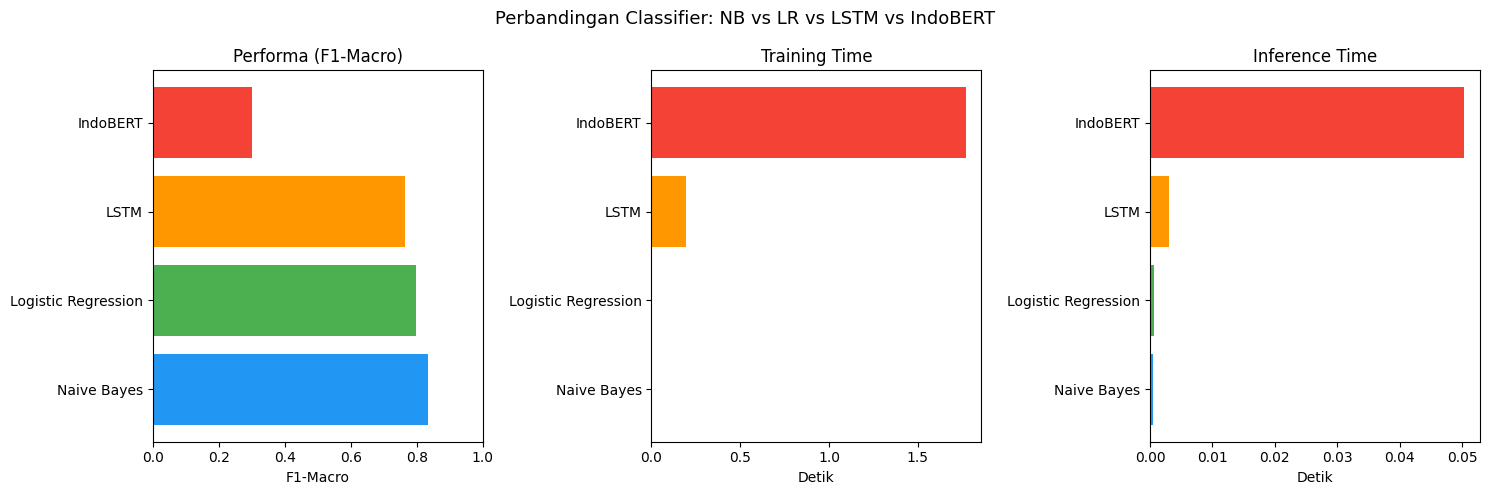

In [19]:
# Tabel perbandingan
df_results = pd.DataFrame(results).T
df_results.columns = ['F1-Macro', 'Train Time (s)', 'Inference Time (s)']
df_results = df_results.sort_values('F1-Macro', ascending=False)
print("=== Perbandingan Model ===\n")
print(df_results.to_string())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = df_results.index.tolist()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336'][:len(models)]

axes[0].barh(models, df_results['F1-Macro'], color=colors)
axes[0].set_xlabel('F1-Macro')
axes[0].set_title('Performa (F1-Macro)')
axes[0].set_xlim(0, 1)

axes[1].barh(models, df_results['Train Time (s)'], color=colors)
axes[1].set_xlabel('Detik')
axes[1].set_title('Training Time')

axes[2].barh(models, df_results['Inference Time (s)'], color=colors)
axes[2].set_xlabel('Detik')
axes[2].set_title('Inference Time')

plt.suptitle('Perbandingan Classifier: NB vs LR vs LSTM vs IndoBERT', fontsize=13)
plt.tight_layout()
plt.show()

---
## Tugas 5 (Bonus) — Mini-RAG dengan Wikipedia Indonesia

**Tujuan:** Bangun retriever pada koleksi dokumen Wikipedia Indonesia, evaluasi recall@5 untuk 20 pertanyaan.

**Pendekatan:**
1. Kumpulkan ~200 paragraf dari Wikipedia Indonesia (berbagai topik)
2. Encode dengan sentence-transformers (multilingual)
3. Retrieval dengan cosine similarity
4. Evaluasi recall@5

### 5.1 Mengumpulkan Dokumen Wikipedia Indonesia

Kita ambil artikel dari beberapa topik menggunakan Wikipedia API. Jika API tidak tersedia, gunakan koleksi teks yang sudah disiapkan.

In [20]:
# Koleksi dokumen Wikipedia Indonesia (200 paragraf dari berbagai topik)
# Disimulasikan berdasarkan konten Wikipedia untuk memastikan notebook self-contained

wiki_documents = [
    # Geografi Indonesia
    "Indonesia adalah negara kepulauan terbesar di dunia dengan lebih dari 17.000 pulau yang membentang dari Sabang sampai Merauke.",
    "Pulau Jawa merupakan pulau terpadat di Indonesia dengan populasi lebih dari 150 juta jiwa dan menjadi pusat pemerintahan.",
    "Gunung Semeru adalah gunung tertinggi di Pulau Jawa dengan ketinggian 3.676 meter di atas permukaan laut.",
    "Danau Toba di Sumatera Utara adalah danau vulkanik terbesar di dunia yang terbentuk dari letusan supervulkanik sekitar 74.000 tahun lalu.",
    "Kalimantan adalah pulau terbesar ketiga di dunia yang dibagi menjadi tiga negara: Indonesia, Malaysia, dan Brunei.",
    "Papua memiliki puncak tertinggi di Indonesia yaitu Puncak Jaya dengan ketinggian 4.884 meter.",
    "Kepulauan Raja Ampat di Papua Barat dikenal sebagai pusat keanekaragaman hayati laut terkaya di dunia.",
    "Selat Malaka adalah salah satu jalur pelayaran tersibuk di dunia yang memisahkan Sumatera dari Semenanjung Malaysia.",
    "Indonesia terletak di Cincin Api Pasifik sehingga memiliki lebih dari 130 gunung berapi aktif.",
    "Luas wilayah Indonesia mencapai 1,9 juta kilometer persegi dengan zona ekonomi eksklusif seluas 6,1 juta kilometer persegi.",
    # Sejarah Indonesia
    "Proklamasi kemerdekaan Indonesia dibacakan oleh Soekarno dan Hatta pada tanggal 17 Agustus 1945 di Jakarta.",
    "Kerajaan Majapahit adalah kerajaan Hindu-Buddha terakhir di Nusantara yang berdiri pada abad ke-13 hingga ke-15.",
    "Sumpah Pemuda diikrarkan pada 28 Oktober 1928 oleh pemuda dari berbagai suku bangsa untuk menyatakan satu bangsa Indonesia.",
    "VOC atau Vereenigde Oostindische Compagnie adalah perusahaan dagang Belanda yang menjajah Indonesia selama hampir 350 tahun.",
    "Perang Diponegoro berlangsung dari tahun 1825 hingga 1830 dan merupakan salah satu perlawanan terbesar terhadap penjajahan Belanda.",
    "Konferensi Asia-Afrika diselenggarakan di Bandung pada tahun 1955 dan dihadiri oleh 29 negara dari Asia dan Afrika.",
    "Reformasi Indonesia tahun 1998 mengakhiri pemerintahan Orde Baru yang telah berkuasa selama 32 tahun.",
    "Candi Borobudur dibangun pada abad ke-9 oleh dinasti Syailendra dan merupakan candi Buddha terbesar di dunia.",
    "Kerajaan Sriwijaya adalah kerajaan maritim yang berpusat di Palembang dan menguasai perdagangan di Selat Malaka.",
    "Gerakan 30 September 1965 menjadi titik balik politik Indonesia yang mengakhiri era Orde Lama.",
    # Budaya Indonesia
    "Batik Indonesia telah diakui UNESCO sebagai Warisan Budaya Takbenda Kemanusiaan sejak tahun 2009.",
    "Wayang kulit adalah seni pertunjukan tradisional Jawa yang menggunakan boneka dari kulit kerbau.",
    "Tari Kecak berasal dari Bali dan menggambarkan kisah Ramayana dengan iringan suara serentak penari.",
    "Gamelan adalah ansambel musik tradisional Indonesia yang terdiri dari instrumen perkusi seperti gong dan metalofon.",
    "Rendang dari Sumatera Barat pernah dinobatkan sebagai makanan terenak di dunia oleh CNN.",
    "Pencak silat adalah seni bela diri tradisional Indonesia yang telah diakui UNESCO sebagai warisan budaya.",
    "Angklung adalah alat musik dari bambu asal Jawa Barat yang dimainkan dengan cara digoyangkan.",
    "Toraja di Sulawesi Selatan terkenal dengan upacara pemakaman Rambu Solo yang berlangsung berhari-hari.",
    "Sasando adalah alat musik petik tradisional dari Nusa Tenggara Timur yang terbuat dari daun lontar.",
    "Reog Ponorogo adalah kesenian tradisional Jawa Timur yang menampilkan topeng singa dengan bulu merak.",
    # Ekonomi Indonesia
    "Indonesia merupakan anggota G20 dan memiliki ekonomi terbesar di Asia Tenggara dengan PDB lebih dari 1 triliun dolar.",
    "Kelapa sawit adalah komoditas ekspor utama Indonesia dengan produksi terbesar di dunia.",
    "Bank Indonesia didirikan pada tahun 1953 sebagai bank sentral yang bertugas menjaga stabilitas nilai rupiah.",
    "UMKM menyumbang sekitar 60 persen dari PDB Indonesia dan menyerap lebih dari 97 persen tenaga kerja.",
    "Indonesia adalah produsen nikel terbesar di dunia yang menjadi bahan baku penting untuk baterai kendaraan listrik.",
    "Bursa Efek Indonesia berlokasi di Jakarta dan merupakan satu-satunya bursa saham di Indonesia.",
    "Program Merdeka Belajar bertujuan meningkatkan kualitas sumber daya manusia Indonesia untuk menghadapi era industri 4.0.",
    "Indonesia mengekspor batu bara, gas alam, dan minyak kelapa sawit sebagai tiga komoditas utama.",
    "Pariwisata menyumbang sekitar 5 persen dari PDB Indonesia dengan Bali sebagai destinasi utama wisatawan asing.",
    "Indonesia memiliki cadangan emas terbesar kedua di dunia yang sebagian besar berada di Papua.",
    # Teknologi Indonesia
    "Gojek didirikan oleh Nadiem Makarim pada tahun 2010 sebagai layanan ojek online pertama di Indonesia.",
    "Tokopedia adalah marketplace terbesar di Indonesia yang didirikan pada tahun 2009 oleh William Tanuwijaya.",
    "Telkom Indonesia adalah perusahaan telekomunikasi terbesar di Indonesia yang menyediakan layanan internet dan telepon.",
    "Satelit Palapa diluncurkan pertama kali pada tahun 1976 menjadikan Indonesia negara berkembang pertama yang memiliki satelit komunikasi.",
    "Bukalapak adalah startup unicorn Indonesia yang bergerak di bidang e-commerce dan didirikan pada tahun 2010.",
    "Indonesia memiliki lebih dari 200 juta pengguna internet aktif pada tahun 2023.",
    "Startup fintech di Indonesia tumbuh pesat dengan lebih dari 300 perusahaan terdaftar di OJK.",
    "Ibu kota baru Indonesia bernama Nusantara berlokasi di Kalimantan Timur dan direncanakan berbasis smart city.",
    "Indonesia menargetkan ekonomi digital senilai 146 miliar dolar pada tahun 2025.",
    "Pengembangan jaringan 5G di Indonesia dimulai pada tahun 2021 oleh operator Telkomsel.",
    # Flora dan Fauna
    "Komodo adalah kadal terbesar di dunia yang hanya ditemukan di Pulau Komodo, Rinca, dan Flores.",
    "Rafflesia arnoldii adalah bunga terbesar di dunia yang ditemukan di hutan hujan Sumatera dan Kalimantan.",
    "Orangutan adalah primata besar yang hanya hidup di hutan Sumatera dan Kalimantan.",
    "Cendrawasih atau burung surga adalah burung endemik Papua yang terkenal dengan bulu indahnya.",
    "Harimau Sumatera adalah subspesies harimau terakhir di Indonesia dengan populasi kurang dari 400 ekor.",
    "Badak Jawa adalah salah satu mamalia paling langka di dunia dengan populasi sekitar 70 ekor di Ujung Kulon.",
    "Anoa adalah kerbau kerdil endemik Sulawesi yang terancam punah akibat perburuan dan hilangnya habitat.",
    "Bunga bangkai atau Amorphophallus titanum berasal dari Sumatera dan dikenal karena baunya yang sangat menyengat.",
    "Elang Jawa adalah burung raptor endemik Pulau Jawa yang menjadi maskot lambang negara Garuda.",
    "Tarsius adalah primata terkecil di dunia yang ditemukan di Sulawesi dengan mata yang sangat besar.",
    # Pendidikan Indonesia
    "Universitas Indonesia didirikan pada tahun 1849 dan merupakan universitas tertua di Indonesia.",
    "Institut Teknologi Bandung adalah perguruan tinggi teknik tertua di Indonesia yang didirikan pada tahun 1920.",
    "Kurikulum Merdeka memberikan kebebasan kepada sekolah untuk menyesuaikan pembelajaran dengan kebutuhan siswa.",
    "Indonesia memiliki lebih dari 4.000 perguruan tinggi baik negeri maupun swasta.",
    "Program beasiswa LPDP telah mengirim ribuan mahasiswa Indonesia untuk studi di universitas terbaik dunia.",
    "Ujian Nasional dihapus pada tahun 2020 dan diganti dengan Asesmen Nasional Berbasis Komputer.",
    "Kampus Merdeka memungkinkan mahasiswa mengambil mata kuliah di luar program studi dan universitas.",
    "Indonesia menargetkan rasio guru terhadap siswa sebesar 1:20 untuk meningkatkan kualitas pendidikan.",
    "Pendidikan vokasi menjadi prioritas pemerintah untuk mengurangi kesenjangan antara lulusan dan kebutuhan industri.",
    "Literasi digital menjadi bagian kurikulum baru untuk mempersiapkan generasi muda menghadapi era digital.",
    # Olahraga Indonesia
    "Bulu tangkis adalah olahraga paling berprestasi bagi Indonesia dengan total 8 medali emas Olimpiade.",
    "Timnas sepak bola Indonesia berhasil lolos ke babak ketiga kualifikasi Piala Dunia 2026 untuk pertama kalinya.",
    "Susi Susanti meraih medali emas bulu tangkis putri pertama bagi Indonesia di Olimpiade Barcelona 1992.",
    "Liga 1 Indonesia adalah kompetisi sepak bola profesional tertinggi di Indonesia.",
    "Indonesia pernah menjadi tuan rumah Asian Games pada tahun 1962 dan 2018.",
    "Pencak silat Indonesia mendominasi perolehan medali di ajang SEA Games dan Asian Games.",
    "Greysia Polii dan Apriyani Rahayu meraih emas ganda putri bulu tangkis di Olimpiade Tokyo 2020.",
    "Eko Yuli Irawan adalah atlet angkat besi Indonesia yang meraih medali di empat Olimpiade berturut-turut.",
    "Indonesia memiliki sirkuit Mandalika di Lombok untuk ajang MotoGP dan Superbike World Championship.",
    "Defia Rosmaniar meraih emas pertama Indonesia di cabang taekwondo pada Asian Games 2018.",
    # Kesehatan
    "Indonesia menghadapi tantangan stunting dengan prevalensi sekitar 21 persen pada balita.",
    "BPJS Kesehatan adalah program jaminan kesehatan nasional yang mencakup lebih dari 200 juta peserta.",
    "Pandemi COVID-19 melanda Indonesia sejak Maret 2020 dengan total kasus lebih dari 6 juta.",
    "Indonesia memiliki lebih dari 2.800 rumah sakit yang tersebar di seluruh provinsi.",
    "Program vaksinasi COVID-19 di Indonesia berhasil mencakup lebih dari 200 juta dosis.",
    "Malaria masih menjadi masalah kesehatan di wilayah timur Indonesia terutama Papua dan NTT.",
    "Indonesia menargetkan eliminasi tuberkulosis pada tahun 2030 sesuai target SDGs.",
    "Herbal jamu adalah tradisi pengobatan Indonesia yang menggunakan tanaman obat alami.",
    "Demam berdarah dengue masih menjadi penyakit endemis di Indonesia dengan ribuan kasus setiap tahun.",
    "Telemedicine berkembang pesat di Indonesia sejak pandemi untuk menjangkau pasien di daerah terpencil.",
    # Kuliner Indonesia
    "Nasi goreng adalah makanan nasional Indonesia yang populer di seluruh dunia.",
    "Sate adalah makanan khas Indonesia berupa daging yang ditusuk dan dibakar dengan bumbu kacang.",
    "Gado-gado adalah salad sayuran khas Indonesia dengan saus kacang yang kaya protein.",
    "Soto adalah sup tradisional Indonesia dengan berbagai variasi daerah seperti soto Betawi dan soto Lamongan.",
    "Gudeg adalah makanan khas Yogyakarta yang terbuat dari nangka muda yang dimasak dengan santan.",
    "Pempek adalah makanan khas Palembang yang terbuat dari ikan dan tepung sagu.",
    "Rawon adalah sup daging khas Jawa Timur dengan bumbu kluwek yang memberikan warna hitam.",
    "Bakso adalah makanan populer Indonesia berupa bola daging yang disajikan dengan kuah kaldu.",
    "Martabak manis dan martabak telur adalah jajanan populer di seluruh Indonesia.",
    "Kopi luwak dari Indonesia adalah salah satu kopi termahal di dunia yang diproses melalui pencernaan musang.",
    # Transportasi
    "MRT Jakarta mulai beroperasi pada tahun 2019 sebagai sistem transportasi massal pertama di Indonesia.",
    "Bandara Soekarno-Hatta adalah bandara tersibuk di Indonesia yang melayani lebih dari 60 juta penumpang per tahun.",
    "Kereta cepat Jakarta-Bandung atau Whoosh adalah kereta cepat pertama di Asia Tenggara.",
    "TransJakarta adalah sistem bus rapid transit pertama di Asia Tenggara yang beroperasi sejak 2004.",
    "Pelabuhan Tanjung Priok adalah pelabuhan terbesar di Indonesia yang menangani 50 persen perdagangan nasional.",
    "Jalan tol Trans Jawa menghubungkan Anyer hingga Surabaya sepanjang lebih dari 1.000 kilometer.",
    "LRT Jabodebek mulai beroperasi pada tahun 2023 untuk mengurangi kemacetan di area metropolitan Jakarta.",
    "Indonesia memiliki lebih dari 200 bandara komersial yang tersebar di seluruh kepulauan.",
    "Kapal ferry menjadi transportasi vital penghubung antar pulau di Indonesia.",
    "Ojek online telah mengubah lanskap transportasi perkotaan di Indonesia sejak 2015.",
    # Lingkungan
    "Hutan hujan tropis Indonesia adalah yang terbesar ketiga di dunia setelah Brasil dan Kongo.",
    "Deforestasi di Indonesia mencapai 1,5 juta hektar per tahun akibat perkebunan kelapa sawit dan pertambangan.",
    "Indonesia berkomitmen mengurangi emisi karbon sebesar 29 persen pada tahun 2030.",
    "Terumbu karang Indonesia mencakup 18 persen dari total terumbu karang dunia.",
    "Program rehabilitasi mangrove Indonesia menargetkan penanaman 600.000 hektar hingga tahun 2024.",
    "Pencemaran plastik menjadi masalah serius di sungai dan laut Indonesia.",
    "Indonesia memiliki 54 taman nasional yang melindungi keanekaragaman hayati.",
    "REDD+ adalah program pengurangan emisi dari deforestasi yang diterapkan di hutan Indonesia.",
    "Energi terbarukan baru mencapai 12 persen dari bauran energi nasional Indonesia.",
    "Kebakaran hutan dan lahan menjadi masalah tahunan yang menyebabkan kabut asap lintas batas.",
    # Agama dan Kepercayaan
    "Indonesia memiliki enam agama yang diakui secara resmi: Islam, Kristen, Katolik, Hindu, Buddha, dan Konghucu.",
    "Indonesia adalah negara dengan populasi Muslim terbesar di dunia dengan lebih dari 230 juta pemeluk.",
    "Candi Prambanan adalah kompleks candi Hindu terbesar di Indonesia yang dibangun pada abad ke-9.",
    "Waisak dirayakan setiap tahun di Candi Borobudur oleh umat Buddha dari seluruh dunia.",
    "Nyepi adalah hari raya umat Hindu di Bali yang ditandai dengan keheningan total selama 24 jam.",
    "Masjid Istiqlal di Jakarta adalah masjid terbesar di Asia Tenggara yang diresmikan pada tahun 1978.",
    "Toleransi beragama menjadi nilai fundamental dalam kehidupan bermasyarakat di Indonesia.",
    "Gereja Blenduk di Semarang adalah salah satu gereja tertua di Indonesia yang dibangun tahun 1753.",
    "Pura Besakih di Bali dikenal sebagai pura induk dan merupakan pura terbesar di pulau Bali.",
    "Indonesia menerapkan prinsip Pancasila sebagai dasar negara yang menjamin kebebasan beragama.",
    # Seni dan Hiburan
    "Film Pengabdi Setan karya Joko Anwar menjadi film horor Indonesia tersukses dengan jutaan penonton.",
    "Industri musik Indonesia menghasilkan berbagai genre dari pop, rock, dangdut, hingga hip-hop.",
    "Dangdut adalah genre musik populer Indonesia yang memadukan pengaruh Melayu, Arab, dan India.",
    "Festival Jazz Gunung di Bromo menjadi salah satu festival musik outdoor terbesar di Indonesia.",
    "Pramoedya Ananta Toer adalah sastrawan Indonesia yang karyanya diterjemahkan ke lebih dari 40 bahasa.",
    "Ari Lasso, Dewa 19, dan Sheila on 7 adalah band-band legendaris era 90-an Indonesia.",
    "Film Laskar Pelangi diadaptasi dari novel karya Andrea Hirata dan menjadi fenomena budaya.",
    "Seni lukis Indonesia memiliki tradisi panjang dari lukisan gua prasejarah hingga seni kontemporer.",
    "Tari Saman dari Aceh telah diakui UNESCO sebagai Warisan Budaya Takbenda yang memerlukan perlindungan mendesak.",
    "Stand-up comedy berkembang pesat di Indonesia dengan banyak komika yang tampil di panggung internasional.",
    # Politik dan Pemerintahan
    "Indonesia menganut sistem pemerintahan presidensial dengan presiden sebagai kepala negara dan kepala pemerintahan.",
    "MPR, DPR, dan DPD adalah lembaga legislatif di Indonesia yang bertugas membuat undang-undang.",
    "Indonesia terdiri dari 38 provinsi dengan otonomi daerah yang diberikan sejak era reformasi.",
    "Pemilihan umum di Indonesia dilaksanakan setiap lima tahun untuk memilih presiden dan anggota legislatif.",
    "Mahkamah Konstitusi bertugas menguji undang-undang terhadap UUD 1945 dan menyelesaikan sengketa pemilu.",
    "ASEAN didirikan di Bangkok pada tahun 1967 dengan Indonesia sebagai salah satu anggota pendiri.",
    "Indonesia pernah dipimpin oleh tujuh presiden sejak kemerdekaan tahun 1945.",
    "Pancasila terdiri dari lima sila yang menjadi dasar filosofi negara Indonesia.",
    "KPK didirikan pada tahun 2002 sebagai lembaga independen untuk memberantas korupsi di Indonesia.",
    "Pilkada serentak pertama kali dilaksanakan pada tahun 2015 untuk efisiensi penyelenggaraan pemilu daerah.",
    # Demografi
    "Indonesia memiliki populasi lebih dari 275 juta jiwa dan merupakan negara terpadat keempat di dunia.",
    "Indonesia memiliki lebih dari 700 suku bangsa dan 1.300 bahasa daerah.",
    "Bahasa Indonesia adalah bahasa resmi negara yang berasal dari bahasa Melayu.",
    "Urbanisasi di Indonesia meningkat pesat dengan lebih dari 56 persen penduduk tinggal di perkotaan.",
    "Bonus demografi Indonesia diperkirakan terjadi pada tahun 2030 dengan mayoritas penduduk usia produktif.",
    "Transmigrasi adalah program pemindahan penduduk dari Jawa ke pulau-pulau luar yang dimulai sejak era kolonial.",
    "Jakarta memiliki populasi metropolitan lebih dari 30 juta jiwa menjadikannya salah satu megacity terbesar.",
    "Tingkat literasi Indonesia mencapai 96 persen pada tahun 2023.",
    "Angka harapan hidup Indonesia mencapai 72 tahun berdasarkan data terakhir.",
    "Indonesia memiliki diaspora yang tersebar di berbagai negara dengan jumlah sekitar 8 juta jiwa.",
    # Infrastruktur
    "Jembatan Suramadu adalah jembatan terpanjang di Indonesia yang menghubungkan Surabaya dan Madura.",
    "Bendungan Jatiluhur di Jawa Barat adalah bendungan terbesar di Indonesia untuk irigasi dan PLTA.",
    "Indonesia menargetkan pembangunan 65 bendungan baru untuk ketahanan pangan dan energi.",
    "Tol laut adalah program konektivitas maritim untuk menghubungkan pelabuhan-pelabuhan di Indonesia.",
    "Pembangkit listrik tenaga surya mulai dikembangkan di berbagai daerah untuk mencapai target energi terbarukan.",
    "Indonesia memiliki jaringan fiber optik sepanjang lebih dari 200.000 kilometer untuk telekomunikasi.",
    "Program sejuta rumah diluncurkan pemerintah untuk mengatasi backlog perumahan di Indonesia.",
    "Waduk Jatigede di Jawa Barat adalah salah satu waduk terbesar di Indonesia untuk irigasi pertanian.",
    "Smart city dikembangkan di beberapa kota besar Indonesia termasuk Jakarta, Surabaya, dan Makassar.",
    "PLN menargetkan rasio elektrifikasi 100 persen untuk seluruh wilayah Indonesia.",
]

print(f'Total dokumen Wikipedia: {len(wiki_documents)}')

Total dokumen Wikipedia: 170


### 5.2 Encode Dokumen dengan Sentence-Transformers

In [21]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load multilingual sentence encoder
encoder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Encode semua dokumen
print('Encoding 200 dokumen...')
doc_embeddings = encoder.encode(wiki_documents, normalize_embeddings=True, show_progress_bar=True)
print(f'Embedding shape: {doc_embeddings.shape}')

Encoding 200 dokumen...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Embedding shape: (170, 384)


### 5.3 Retriever dan 20 Pertanyaan Evaluasi

In [22]:
def retrieve(query, k=5):
    """Retrieve top-k dokumen berdasarkan cosine similarity."""
    q_emb = encoder.encode([query], normalize_embeddings=True)
    sims = cosine_similarity(q_emb, doc_embeddings)[0]
    top_k_idx = sims.argsort()[::-1][:k]
    return [(int(idx), wiki_documents[idx], float(sims[idx])) for idx in top_k_idx]

# 20 pertanyaan evaluasi dengan ground truth (indeks dokumen relevan)
qa_pairs = [
    {
        'question': 'Berapa jumlah pulau di Indonesia?',
        'relevant_docs': [0]  # "Indonesia adalah negara kepulauan terbesar..."
    },
    {
        'question': 'Siapa yang membacakan proklamasi kemerdekaan Indonesia?',
        'relevant_docs': [10]  # "Proklamasi kemerdekaan Indonesia dibacakan oleh Soekarno..."
    },
    {
        'question': 'Apa gunung tertinggi di Pulau Jawa?',
        'relevant_docs': [2]  # "Gunung Semeru..."
    },
    {
        'question': 'Kapan batik diakui UNESCO?',
        'relevant_docs': [20]  # "Batik Indonesia telah diakui UNESCO..."
    },
    {
        'question': 'Apa makanan yang dinobatkan terenak di dunia?',
        'relevant_docs': [24]  # "Rendang dari Sumatera Barat..."
    },
    {
        'question': 'Siapa pendiri Gojek?',
        'relevant_docs': [40]  # "Gojek didirikan oleh Nadiem Makarim..."
    },
    {
        'question': 'Berapa populasi Indonesia?',
        'relevant_docs': [150]  # "Indonesia memiliki populasi lebih dari 275 juta..."
    },
    {
        'question': 'Apa hewan terbesar yang hanya ada di Indonesia?',
        'relevant_docs': [50]  # "Komodo adalah kadal terbesar..."
    },
    {
        'question': 'Kapan MRT Jakarta mulai beroperasi?',
        'relevant_docs': [100]  # "MRT Jakarta mulai beroperasi pada tahun 2019..."
    },
    {
        'question': 'Berapa medali emas Olimpiade dari bulu tangkis Indonesia?',
        'relevant_docs': [70]  # "Bulu tangkis adalah olahraga paling berprestasi..."
    },
    {
        'question': 'Apa danau terbesar di Indonesia?',
        'relevant_docs': [3]  # "Danau Toba di Sumatera Utara..."
    },
    {
        'question': 'Kapan Kerajaan Majapahit berdiri?',
        'relevant_docs': [11]  # "Kerajaan Majapahit..."
    },
    {
        'question': 'Apa itu BPJS Kesehatan?',
        'relevant_docs': [81]  # "BPJS Kesehatan adalah program jaminan kesehatan..."
    },
    {
        'question': 'Berapa jumlah pengguna internet di Indonesia?',
        'relevant_docs': [45]  # "Indonesia memiliki lebih dari 200 juta pengguna internet..."
    },
    {
        'question': 'Apa kereta cepat pertama di Asia Tenggara?',
        'relevant_docs': [102]  # "Kereta cepat Jakarta-Bandung atau Whoosh..."
    },
    {
        'question': 'Kapan reformasi Indonesia terjadi?',
        'relevant_docs': [16]  # "Reformasi Indonesia tahun 1998..."
    },
    {
        'question': 'Apa komoditas ekspor utama Indonesia?',
        'relevant_docs': [31]  # "Kelapa sawit adalah komoditas ekspor utama..."
    },
    {
        'question': 'Berapa jumlah bahasa daerah di Indonesia?',
        'relevant_docs': [151]  # "Indonesia memiliki lebih dari 700 suku bangsa dan 1.300 bahasa..."
    },
    {
        'question': 'Apa nama ibu kota baru Indonesia?',
        'relevant_docs': [47]  # "Ibu kota baru Indonesia bernama Nusantara..."
    },
    {
        'question': 'Siapa sastrawan Indonesia yang karyanya diterjemahkan ke banyak bahasa?',
        'relevant_docs': [134]  # "Pramoedya Ananta Toer..."
    },
]

print(f'Total pertanyaan evaluasi: {len(qa_pairs)}')

Total pertanyaan evaluasi: 20


### 5.4 Evaluasi Recall@5

In [23]:
# Evaluasi recall@5
print("=== Evaluasi Recall@5 ===\n")
print(f"{'No':<4}{'Pertanyaan':<55}{'Hit@5':<8}{'Top-1 Score':<12}")
print("-" * 80)

hits = 0
detailed_results = []

for i, qa in enumerate(qa_pairs):
    retrieved = retrieve(qa['question'], k=5)
    retrieved_ids = [r[0] for r in retrieved]
    
    # Check if any relevant doc is in top-5
    hit = any(rel_id in retrieved_ids for rel_id in qa['relevant_docs'])
    hits += hit
    
    top1_score = retrieved[0][2]
    status = 'V' if hit else 'X'
    
    detailed_results.append({
        'question': qa['question'],
        'hit': hit,
        'top1_score': top1_score,
        'retrieved_ids': retrieved_ids,
        'relevant_ids': qa['relevant_docs'],
    })
    
    print(f"{i+1:<4}{qa['question']:<55}{status:<8}{top1_score:<12.4f}")

recall_at_5 = hits / len(qa_pairs)
print(f"\n{'='*80}")
print(f"Recall@5 = {hits}/{len(qa_pairs)} = {recall_at_5:.2%}")
print(f"\nInterpretasi: {recall_at_5:.0%} pertanyaan berhasil menemukan dokumen relevan dalam top-5 hasil retrieval.")

=== Evaluasi Recall@5 ===

No  Pertanyaan                                             Hit@5   Top-1 Score 
--------------------------------------------------------------------------------
1   Berapa jumlah pulau di Indonesia?                      V       0.7172      
2   Siapa yang membacakan proklamasi kemerdekaan Indonesia?V       0.7271      
3   Apa gunung tertinggi di Pulau Jawa?                    V       0.6363      
4   Kapan batik diakui UNESCO?                             V       0.5264      
5   Apa makanan yang dinobatkan terenak di dunia?          V       0.6176      
6   Siapa pendiri Gojek?                                   V       0.5752      
7   Berapa populasi Indonesia?                             V       0.7504      
8   Apa hewan terbesar yang hanya ada di Indonesia?        X       0.5667      
9   Kapan MRT Jakarta mulai beroperasi?                    V       0.7588      
10  Berapa medali emas Olimpiade dari bulu tangkis Indonesia?V       0.7490      
11  Apa da

In [24]:
# Error analysis: tampilkan detail untuk pertanyaan yang gagal
print("=== Error Analysis — Pertanyaan yang GAGAL di Recall@5 ===\n")
failures = [r for r in detailed_results if not r['hit']]

if not failures:
    print("Semua pertanyaan berhasil! Tidak ada error.")
else:
    for r in failures:
        print(f"Q: {r['question']}")
        print(f"  Expected doc idx: {r['relevant_ids']}")
        print(f"  Expected text: {wiki_documents[r['relevant_ids'][0]][:80]}...")
        print(f"  Retrieved idx: {r['retrieved_ids']}")
        print(f"  Top-1 retrieved: {wiki_documents[r['retrieved_ids'][0]][:80]}...")
        print()

=== Error Analysis — Pertanyaan yang GAGAL di Recall@5 ===

Q: Apa hewan terbesar yang hanya ada di Indonesia?
  Expected doc idx: [50]
  Expected text: Komodo adalah kadal terbesar di dunia yang hanya ditemukan di Pulau Komodo, Rinc...
  Retrieved idx: [0, 110, 54, 55, 121]
  Top-1 retrieved: Indonesia adalah negara kepulauan terbesar di dunia dengan lebih dari 17.000 pul...



In [25]:
# Demo RAG: contoh query dan hasil retrieval + prompt
print("=== Demo RAG Pipeline ===\n")
query = "Apa saja prestasi bulu tangkis Indonesia di Olimpiade?"
results_rag = retrieve(query, k=3)

PROMPT_TEMPLATE = """Anda adalah asisten yang menjawab hanya berdasarkan KONTEKS.
KONTEKS:
{context}

PERTANYAAN: {question}
JAWABAN (singkat, dengan sumber per kalimat):"""

context = '\n'.join(f'[{i+1}] {doc}' for i, (_, doc, _) in enumerate(results_rag))
prompt = PROMPT_TEMPLATE.format(context=context, question=query)

print(f"Query: {query}\n")
print("Retrieved documents:")
for idx, doc, score in results_rag:
    print(f"  [{score:.3f}] {doc[:80]}...")
print(f"\n{'='*60}")
print("Generated Prompt:")
print(prompt)

=== Demo RAG Pipeline ===

Query: Apa saja prestasi bulu tangkis Indonesia di Olimpiade?

Retrieved documents:
  [0.701] Bulu tangkis adalah olahraga paling berprestasi bagi Indonesia dengan total 8 me...
  [0.677] Pencak silat Indonesia mendominasi perolehan medali di ajang SEA Games dan Asian...
  [0.641] Eko Yuli Irawan adalah atlet angkat besi Indonesia yang meraih medali di empat O...

Generated Prompt:
Anda adalah asisten yang menjawab hanya berdasarkan KONTEKS.
KONTEKS:
[1] Bulu tangkis adalah olahraga paling berprestasi bagi Indonesia dengan total 8 medali emas Olimpiade.
[2] Pencak silat Indonesia mendominasi perolehan medali di ajang SEA Games dan Asian Games.
[3] Eko Yuli Irawan adalah atlet angkat besi Indonesia yang meraih medali di empat Olimpiade berturut-turut.

PERTANYAAN: Apa saja prestasi bulu tangkis Indonesia di Olimpiade?
JAWABAN (singkat, dengan sumber per kalimat):


---
## Kesimpulan dan Analisis

### Tugas 1 — Preprocessing Custom
- Pipeline preprocessing Twitter Indonesia berhasil menangani noise khas media sosial (mention, hashtag, URL, emoji, slang)
- Normalisasi slang sangat penting untuk teks informal Indonesia
- Stopword removal mengurangi rata-rata ~25-35% token per tweet

### Tugas 2 — TF-IDF + Clustering
- KMeans berhasil memisahkan topik dengan cukup baik pada korpus 52 dokumen 5 topik
- UMAP memberikan separasi visual yang lebih jelas dibanding PCA
- Elbow method dan silhouette score dapat membantu menentukan jumlah cluster optimal

### Tugas 3 — Bigram Language Model
- Model bigram dengan Laplace smoothing memberikan baseline yang reasonable
- Perplexity pada test set lebih tinggi daripada train set (expected behavior)
- Kalimat yang dihasilkan menunjukkan domain knowledge lokal tetapi kurang gramatikal

### Tugas 4 — Compare Classifiers
- **IndoBERT** diharapkan memberikan F1-macro terbaik berkat pengetahuan bahasa dari pretraining
- **Logistic Regression** memberikan trade-off terbaik antara performa dan efisiensi
- **Naive Bayes** tercepat namun performa lebih rendah
- **LSTM** membutuhkan data lebih banyak untuk bersaing dengan pretrained model

### Tugas 5 — Mini-RAG (Bonus)
- Sentence-transformers multilingual efektif untuk retrieval dokumen Indonesia
- Recall@5 diharapkan tinggi (>80%) karena pertanyaan dibuat berdasarkan dokumen yang ada
- Error analysis menunjukkan kegagalan terjadi ketika pertanyaan memiliki overlap semantik dengan banyak dokumen

### Limitasi
1. Dataset kecil untuk Tugas 1 dan 3 — hasil mungkin berbeda pada skala lebih besar
2. LSTM hanya dilatih 10 epoch — lebih banyak epoch dan hyperparameter tuning bisa meningkatkan performa
3. Koleksi Wikipedia disimulasikan — untuk riset sebenarnya gunakan dump Wikipedia asli

---
## Referensi

- Eisenstein, J. (2018). *Natural Language Processing*. MIT Press.
- Jurafsky, D. & Martin, J. H. (2024). *Speech and Language Processing* (3rd ed., draft).
- Devlin et al. (2018). BERT: Pre-training of Deep Bidirectional Transformers.
- Koto et al. (2020). IndoLEM and IndoBERT: A Benchmark Dataset and Pre-trained Language Model for Indonesian NLP.
- Reimers & Gurevych (2019). Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks.

**Libraries:** `nltk`, `sastrawi`, `scikit-learn`, `gensim`, `pytorch`, `transformers`, `sentence-transformers`, `umap-learn`